# Demand

This tutorial covers electricity demand modeling in PyPSA-GB, including historical profiles, future projections, and spatial disaggregation.

## What You'll Learn

- Demand data sources (ESPENI, eLOAD, DESSTINEE)
- Temporal profiles and patterns
- Spatial demand distribution
- Future demand scaling with FES
- Demand-side flexibility

## 1. Setup

In [1]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pyproj import Transformer
from _map_utils import prepare_map_network, explore_network_map

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

print(f"PyPSA version: {pypsa.__version__}")

PyPSA version: 1.0.7


## 2. Demand Data Sources

PyPSA-GB supports multiple demand data sources:

| Source | Type | Resolution | Use Case |
|--------|------|------------|----------|
| **ESPENI** | Historical | Half-hourly, national | Historical scenarios |
| **eLOAD** | Synthetic | Hourly, sectoral | Future projections |
| **DESSTINEE** | Synthetic | Hourly | Alternative future profiles |
| **FES** | Projections | Annual totals | Capacity scaling |

## 3. Load a Network with Demand

In [2]:
# Load a historical network
n = pypsa.Network("../../../resources/network/Historical_2015_reduced_solved.nc")

print("Network loaded")
print(f"  Loads: {len(n.loads)}")
print(f"  Snapshots: {len(n.snapshots)}")
print(f"  Period: {n.snapshots[0]} to {n.snapshots[-1]}")

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Historical_2015_reduced (Full)' has buses, carriers, generators, lines, links, loads, storage_units, sub_networks


Network loaded
  Loads: 35
  Snapshots: 168
  Period: 2015-01-01 00:00:00 to 2015-01-07 23:00:00


## 4. Demand Structure

### 4.1 Loads in PyPSA

In [3]:
# Load components
print("Load DataFrame:")
n.loads.head()

Load DataFrame:


,bus,carrier,type,p_set,q_set,sign,active
name,,,,,,,
load_Beauly,Beauly,electricity,,0.0,0.0,-1.0,True
load_Peterhead,Peterhead,electricity,,0.0,0.0,-1.0,True
load_Errochty,Errochty,electricity,,0.0,0.0,-1.0,True
load_Denny/Bonnybridge,Denny/Bonnybridge,electricity,,0.0,0.0,-1.0,True
load_Neilston,Neilston,electricity,,0.0,0.0,-1.0,True


In [4]:
# Demand time series
print("Demand time series shape:", n.loads_t.p_set.shape)
print(f"\nSample demand values (MW):")
n.loads_t.p_set.head()

Demand time series shape: (168, 33)

Sample demand values (MW):


name,load_Beauly,load_Peterhead,load_Errochty,load_Denny/Bonnybridge,load_Neilston,load_Strathaven,load_Torness,load_Eccles,load_Harker,load_Stella West,...,load_Bramley,load_London,load_Kemsley,load_Sellindge,load_Lovedean,load_S.W.Penisula,EU_demand_IFA,EU_demand_Moyle,EU_demand_Auchencrosh (interconnector CCT),EU_demand_East West Interconnector
snapshot,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,125.398540,115.993649,34.484598,250.797080,250.797080,75.239124,106.588759,18.809781,172.422992,1686.610361,...,1225.770727,4790.224222,1147.396640,87.778978,742.986349,2580.074957,0.0,12.666667,13.333333,120.0
2015-01-01 01:00:00,125.460546,116.051005,34.501650,250.921092,250.921092,75.276328,106.641464,18.819082,172.508251,1687.444344,...,1226.376838,4792.592859,1147.963996,87.822382,743.353735,2581.350735,0.0,26.307692,27.692308,120.0
2015-01-01 02:00:00,120.162016,111.149865,33.044554,240.324032,240.324032,72.097210,102.137714,18.024302,165.222772,1616.179118,...,1174.583708,4590.189019,1099.482448,84.113411,711.959946,2472.333483,0.0,40.923077,43.076923,8.0
2015-01-01 03:00:00,114.773477,106.165467,31.562706,229.546955,229.546955,68.864086,97.557456,17.216022,157.813531,1543.703270,...,1121.910741,4384.346835,1050.177318,80.341434,680.032853,2361.464296,0.0,43.846154,46.153846,0.0
2015-01-01 04:00:00,108.474847,100.339234,29.830583,216.949695,216.949695,65.084908,92.203620,16.271227,149.152915,1458.986699,...,1060.341634,4143.739174,992.544854,75.932393,642.713471,2231.869987,1022.0,75.025641,78.974359,0.0


### 4.2 System-Wide Demand

In [5]:
# Total system demand
total_demand = n.loads_t.p_set.sum(axis=1) / 1000  # GW

print("System Demand Statistics (GW):")
print(f"  Mean: {total_demand.mean():.2f}")
print(f"  Peak: {total_demand.max():.2f}")
print(f"  Minimum: {total_demand.min():.2f}")
print(f"  Standard Dev: {total_demand.std():.2f}")

# Total energy
hours = len(n.snapshots)
energy_twh = total_demand.sum() / 1000  # TWh
print(f"\nTotal Energy: {energy_twh:.2f} TWh over {hours} hours")

System Demand Statistics (GW):
  Mean: 38.45
  Peak: 52.46
  Minimum: 27.20
  Standard Dev: 7.22

Total Energy: 6.46 TWh over 168 hours


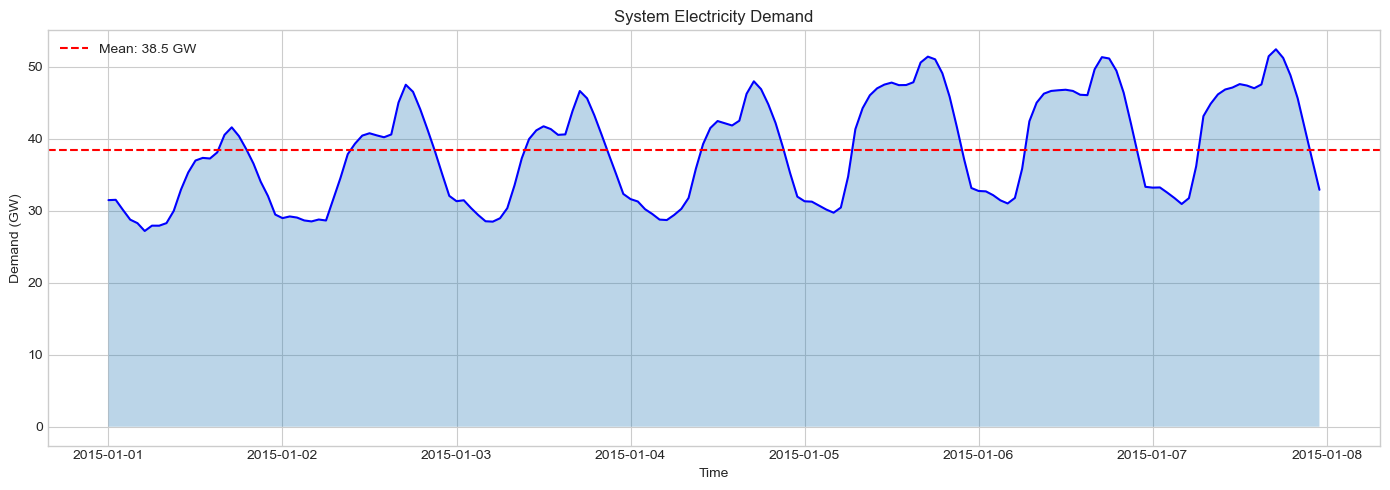

In [6]:
# Plot demand profile
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(total_demand.index, total_demand.values, linewidth=1.5, color='blue')
ax.fill_between(total_demand.index, total_demand.values, alpha=0.3)

ax.axhline(y=total_demand.mean(), color='red', linestyle='--', label=f'Mean: {total_demand.mean():.1f} GW')

ax.set_ylabel('Demand (GW)')
ax.set_xlabel('Time')
ax.set_title('System Electricity Demand')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Temporal Patterns

### 5.1 Daily Pattern

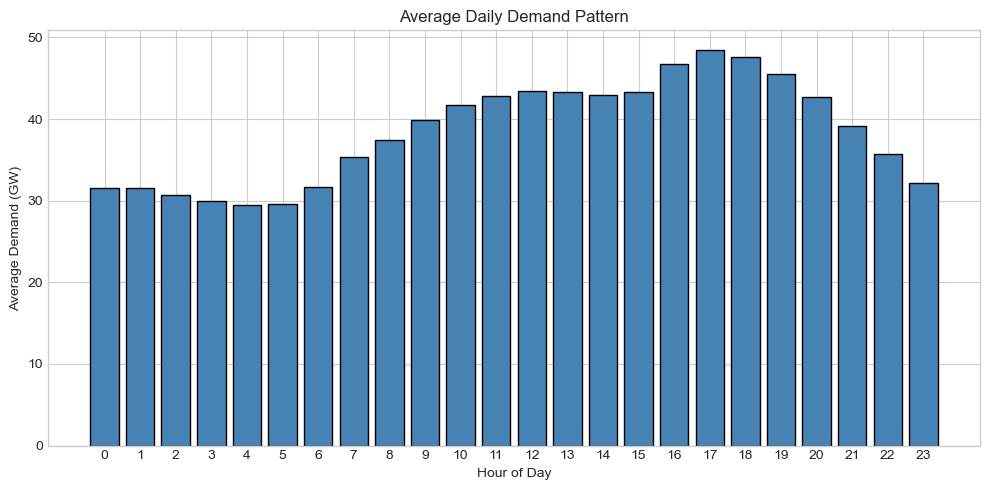

Morning peak: 9:00 (39.94 GW)
Evening peak: 17:00 (48.44 GW)
Night trough: 4:00 (29.41 GW)


In [7]:
# Hourly pattern
demand_df = total_demand.to_frame('demand')
demand_df['hour'] = demand_df.index.hour

hourly_pattern = demand_df.groupby('hour')['demand'].mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(hourly_pattern.index, hourly_pattern.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Demand (GW)')
ax.set_title('Average Daily Demand Pattern')
ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

print(f"Morning peak: {hourly_pattern.loc[7:9].idxmax()}:00 ({hourly_pattern.loc[7:9].max():.2f} GW)")
print(f"Evening peak: {hourly_pattern.loc[17:21].idxmax()}:00 ({hourly_pattern.loc[17:21].max():.2f} GW)")
print(f"Night trough: {hourly_pattern.idxmin()}:00 ({hourly_pattern.min():.2f} GW)")

### 5.2 Load Duration Curve

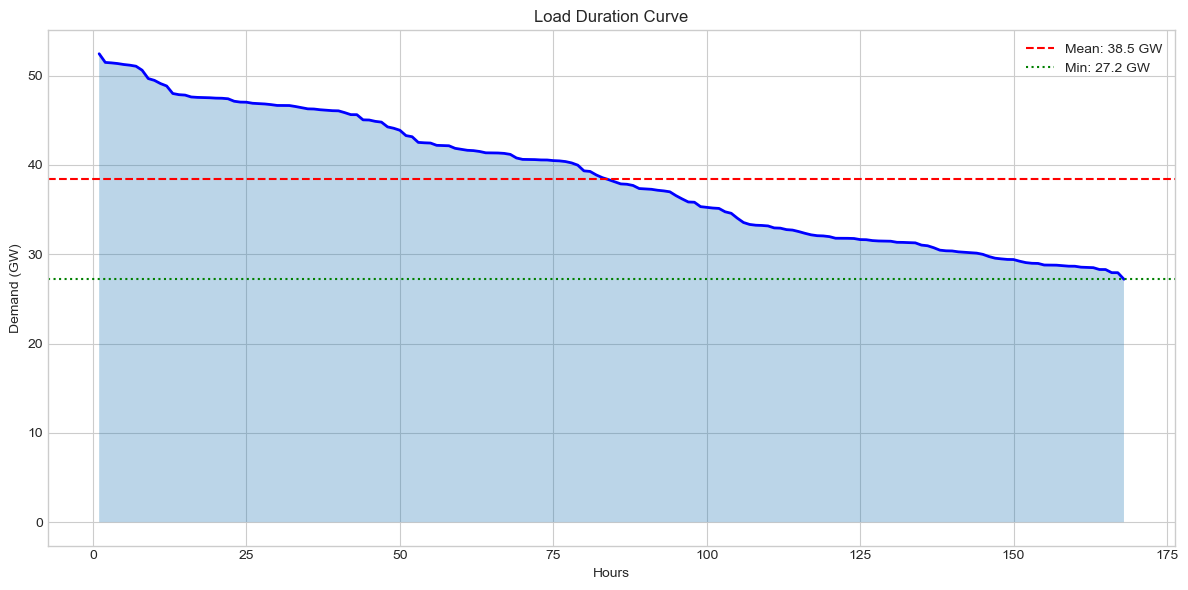

Load Factor: 73.3%


In [8]:
# Load duration curve
sorted_demand = total_demand.sort_values(ascending=False).values
hours = np.arange(1, len(sorted_demand) + 1)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(hours, sorted_demand, linewidth=2, color='blue')
ax.fill_between(hours, sorted_demand, alpha=0.3)

# Mark key points
ax.axhline(y=total_demand.mean(), color='red', linestyle='--', label=f'Mean: {total_demand.mean():.1f} GW')
ax.axhline(y=total_demand.min(), color='green', linestyle=':', label=f'Min: {total_demand.min():.1f} GW')

ax.set_xlabel('Hours')
ax.set_ylabel('Demand (GW)')
ax.set_title('Load Duration Curve')
ax.legend()

plt.tight_layout()
plt.show()

# Load factor
load_factor = total_demand.mean() / total_demand.max() * 100
print(f"Load Factor: {load_factor:.1f}%")

## 6. Spatial Distribution

### 6.1 Demand by Bus

In [9]:
# Average demand at each bus
bus_demand = n.loads_t.p_set.mean() / 1000  # GW

print("Top 10 Buses by Demand (GW):")
print(bus_demand.sort_values(ascending=False).head(10).round(3).to_string())

Top 10 Buses by Demand (GW):
name
load_London                    5.820
load_Melksham                  3.344
load_S.W.Penisula              3.135
load_Daines                    3.013
load_Feckenham                 2.727
load_Deeside                   2.643
load_Stella West               2.049
load_Th. Marsh/Stocksbridge    2.007
load_Sundon/East Claydon       1.603
load_Ratcliffe                 1.554


In [10]:
# Interactive map showing demand distribution
if len(bus_demand) > 0:
    map_n = prepare_map_network(n)

    # Vectorised calculation of average demand per load (MW)
    mean_per_load = n.loads_t.p_set.mean()

    # Keep only loads that actually have a timeseries
    loads_with_ts = n.loads.loc[n.loads.index.intersection(mean_per_load.index)]

    # Join load-to-bus mapping with mean demand and aggregate per bus
    df = loads_with_ts[['bus']].join(mean_per_load.rename('mean_MW'))
    bus_demand_by_bus = df.groupby('bus')['mean_MW'].sum()

    # Reindex to include all buses and fill missing values with 0
    bus_demand_by_bus = bus_demand_by_bus.reindex(n.buses.index).fillna(0.0)

    # Add demand to buses for tooltip display (units: MW)
    map_n.buses["demand_MW"] = bus_demand_by_bus

    # Report any loads that lacked a timeseries (examples shown)
    missing_loads = set(n.loads.index) - set(mean_per_load.index)
    if len(missing_loads) > 0:
        print(f"Warning: {len(missing_loads)} loads have no timeseries and were ignored (examples: {list(missing_loads)[:5]})")

    print("Spatial Demand Distribution (Bus size = average demand)")
    print("lon range:", float(map_n.buses.x.min()), float(map_n.buses.x.max()))
    print("lat range:", float(map_n.buses.y.min()), float(map_n.buses.y.max()))

    # Interactive network map with demand-based bus sizing
    m = map_n.plot.explore(
        map_style="light",
        tooltip=True,
        bus_size=map_n.buses["demand_MW"].clip(lower=10),
        bus_size_factor=0.05,
        branch_width_factor=1.0,
        bus_columns=["demand_MW", "v_nom"],
    )
    display(m)

Spatial Demand Distribution (Bus size = average demand)
lon range: -6.9603353547518845 4.058099999999997
lat range: 50.912041859956986 57.484467069924335


{
  "initialViewState": {
    "bearing": 0,
    "latitude": 53.47093592917482,
    "longitude": -1.8392345746638465,
    "pitch": 0,
    "zoom": 4
  },
  "layers": [
    {
      "@@type": "PathLayer",
      "autoHighlight": true,
      "data": [
        {
          "bus0": "Kemsley",
          "bus1": "HVDC_External_Netherlands_Maasvlakte",
          "color": "darkseagreen",
          "name": "IC_Britned",
          "path": [
            [
              0.7682084062554182,
              51.376013815662866
            ],
            [
              4.058099999999997,
              51.9889
            ]
          ],
          "rgba": [
            143,
            188,
            143,
            230
          ],
          "tooltip_html": "<b>IC_Britned</b>\n<table>\n<tr><td style='font-weight:bold'>bus0:</td><td style='text-align:left'>Kemsley</td></tr>\n<tr><td style='font-weight:bold'>bus1:</td><td style='text-align:left'>HVDC_External_Netherlands_Maasvlakte</td></tr>\n<tr><td style='font-weight:bold'>color:</td><td style='text-align:left'>darkseagreen</td></tr>\n<tr><td style='font-weight:bold'>width:</td><td style='text-align:left'>2</td></tr>\n</table>",
          "width": 2,
          "width_pdk": 2000.0
        },
        {
          "bus0": "Sellindge",
          "bus1": "HVDC_External_France_Calais",
          "color": "darkseagreen",
          "name": "IC_IFA",
          "path": [
            [
              1.1175925500284765,
              51.10492970297485
            ],
            [
              1.8587220233887165,
              50.95130725773047
            ]
          ],
          "rgba": [
            143,
            188,
            143,
            230
          ],
          "tooltip_html": "<b>IC_IFA</b>\n<table>\n<tr><td style='font-weight:bold'>bus0:</td><td style='text-align:left'>Sellindge</td></tr>\n<tr><td style='font-weight:bold'>bus1:</td><td style='text-align:left'>HVDC_External_France_Calais</td></tr>\n<tr><td style='font-weight:bold'>color:</td><td style='text-align:left'>darkseagreen</td></tr>\n<tr><td style='font-weight:bold'>width:</td><td style='text-align:left'>2</td></tr>\n</table>",
          "width": 2,
          "width_pdk": 2000.0
        },
        {
          "bus0": "Neilston",
          "bus1": "HVDC_External_Northern_Ireland",
          "color": "darkseagreen",
          "name": "IC_Moyle",
          "path": [
            [
              -4.414773163610933,
              55.80882688746656
            ],
            [
              -5.933272434597121,
              54.73331062404302
            ]
          ],
          "rgba": [
            143,
            188,
            143,
            230
          ],
          "tooltip_html": "<b>IC_Moyle</b>\n<table>\n<tr><td style='font-weight:bold'>bus0:</td><td style='text-align:left'>Neilston</td></tr>\n<tr><td style='font-weight:bold'>bus1:</td><td style='text-align:left'>HVDC_External_Northern_Ireland</td></tr>\n<tr><td style='font-weight:bold'>color:</td><td style='text-align:left'>darkseagreen</td></tr>\n<tr><td style='font-weight:bold'>width:</td><td style='text-align:left'>2</td></tr>\n</table>",
          "width": 2,
          "width_pdk": 2000.0
        },
        {
          "bus0": "Neilston",
          "bus1": "HVDC_External_Northern_Ireland",
          "color": "darkseagreen",
          "name": "IC_Auchencrosh (interconnector CCT)",
          "path": [
            [
              -4.414773163610933,
              55.80882688746656
            ],
            [
              -5.933272434597121,
              54.73331062404302
            ]
          ],
          "rgba": [
            143,
            188,
            143,
            230
          ],
          "tooltip_html": "<b>IC_Auchencrosh (interconnector...</b>\n<table>\n<tr><td style='font-weight:bold'>bus0:</td><td style='text-align:left'>Neilston</td></tr>\n<tr><td style='font-weight:bold'>bus1:</td><td style='text-align:left'>HVDC_External_Northern_Ireland</td></tr

## 7. Future Demand Projections

### 7.1 Compare Historical vs Future

In [11]:
# Try to load a future scenario for comparison
try:
    n_future = pypsa.Network("../../../resources/network/HT35_clustered_solved.nc")
    future_demand = n_future.loads_t.p_set.sum(axis=1) / 1000
    
    print("Demand Comparison:")
    print(f"\n  Historical 2015:")
    print(f"    Mean: {total_demand.mean():.2f} GW")
    print(f"    Peak: {total_demand.max():.2f} GW")
    
    print(f"\n  Future 2035 HT:")
    print(f"    Mean: {future_demand.mean():.2f} GW")
    print(f"    Peak: {future_demand.max():.2f} GW")
    
    print(f"\n  Change:")
    print(f"    Mean: {(future_demand.mean()/total_demand.mean() - 1)*100:+.1f}%")
    print(f"    Peak: {(future_demand.max()/total_demand.max() - 1)*100:+.1f}%")
except FileNotFoundError:
    print("Future network not found")
    n_future = None

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'HT35_clustered (Clustered)' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


Demand Comparison:

  Historical 2015:
    Mean: 38.45 GW
    Peak: 52.46 GW

  Future 2035 HT:
    Mean: 49.01 GW
    Peak: 60.93 GW

  Change:
    Mean: +27.4%
    Peak: +16.1%


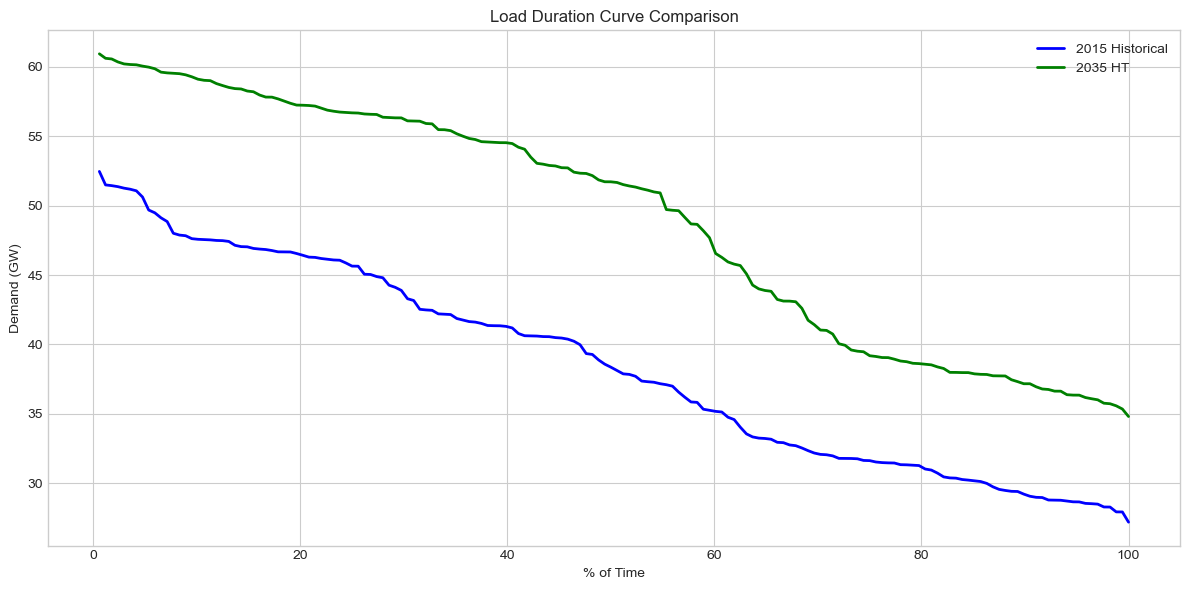

In [12]:
# Compare load duration curves
if n_future is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Historical
    sorted_hist = total_demand.sort_values(ascending=False).values
    hours_hist = np.arange(1, len(sorted_hist) + 1) / len(sorted_hist) * 100
    
    # Future
    sorted_future = future_demand.sort_values(ascending=False).values
    hours_future = np.arange(1, len(sorted_future) + 1) / len(sorted_future) * 100
    
    ax.plot(hours_hist, sorted_hist, linewidth=2, label='2015 Historical', color='blue')
    ax.plot(hours_future, sorted_future, linewidth=2, label='2035 HT', color='green')
    
    ax.set_xlabel('% of Time')
    ax.set_ylabel('Demand (GW)')
    ax.set_title('Load Duration Curve Comparison')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

## 8. Demand vs Generation Balance

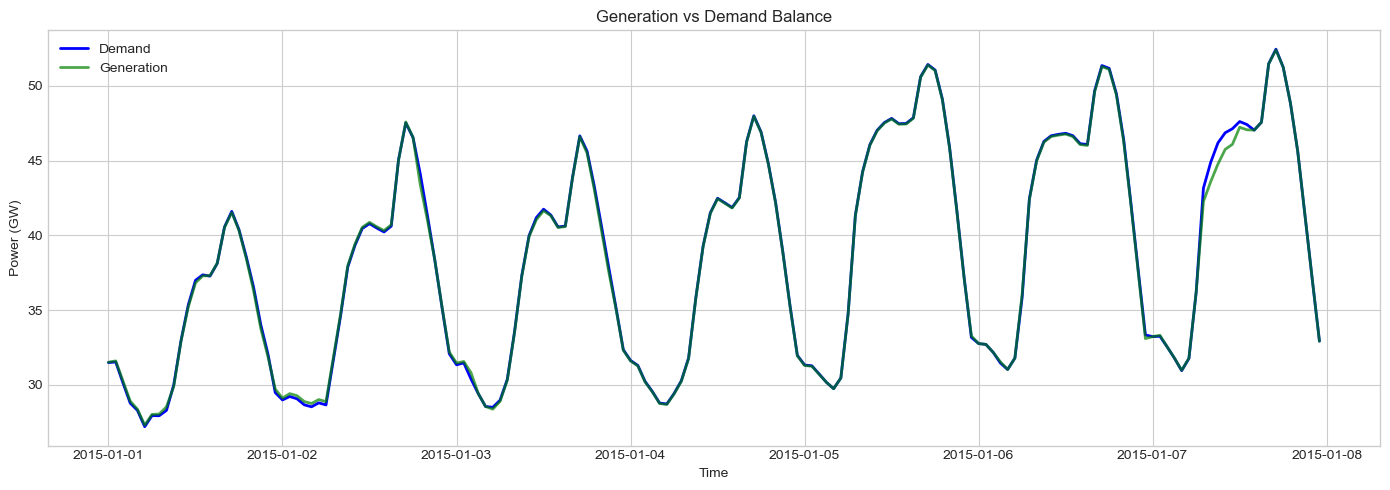

Max imbalance: 1418.1 MW
Average imbalance: 111.7 MW


In [13]:
# Generation vs demand
generation = n.generators_t.p.sum(axis=1) / 1000  # GW

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(total_demand.index, total_demand.values, label='Demand', linewidth=2, color='blue')
ax.plot(generation.index, generation.values, label='Generation', linewidth=2, color='green', alpha=0.7)

ax.set_ylabel('Power (GW)')
ax.set_xlabel('Time')
ax.set_title('Generation vs Demand Balance')
ax.legend()

plt.tight_layout()
plt.show()

# Balance check
imbalance = (generation - total_demand).abs()
print(f"Max imbalance: {imbalance.max()*1000:.1f} MW")
print(f"Average imbalance: {imbalance.mean()*1000:.1f} MW")

## 9. Demand Time Series Configuration

Demand time series can be configured in scenarios:

In [14]:
demand_config = """
# ESPENI (default for historical)
demand_timeseries: "ESPENI"    # Half-hourly national demand

# eLOAD (synthetic profiles)
demand_timeseries: "eload"
profile_year: 2050             # 2010 or 2050 profile year

# DESSTINEE (alternative synthetic)
demand_timeseries: "desstinee"

# Demand disaggregation (future)
demand_disaggregation:
  enabled: true
  components: ["heat_pumps", "EVs"]
"""
print("Demand Configuration Options:")
print(demand_config)

Demand Configuration Options:

# ESPENI (default for historical)
demand_timeseries: "ESPENI"    # Half-hourly national demand

# eLOAD (synthetic profiles)
demand_timeseries: "eload"
profile_year: 2050             # 2010 or 2050 profile year

# DESSTINEE (alternative synthetic)
demand_timeseries: "desstinee"

# Demand disaggregation (future)
demand_disaggregation:
  enabled: true
  components: ["heat_pumps", "EVs"]

